# 04 — Lag structure

Read-only: imports from `src.lag_structure`, `src.point_in_time`, and `scripts.verify_alignment`.

Three links in the supply chain, each measured with `cross_correlation`, plus one `up_down_response` view.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.lag_structure import cross_correlation, up_down_response
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, load_series

DAILY_CRUDE_SERIES_ID = "DCOILWTICO"
WHOLESALE_SERIES_ID = "WGASUSGULF"  # role=core in the manifest — the Gulf Coast series used as "the" wholesale leg throughout

MAX_LAG = 12  # extends past the SPEC's suggested K range so decay into noise is actually visible

COLOR_CRUDE_RETAIL_WEEKLY = "#2a78d6"
COLOR_CRUDE_RETAIL_DAILY_PIT = "#1baf7a"
COLOR_CRUDE_WHOLESALE = "#4a3aa7"
COLOR_WHOLESALE_RETAIL = "#eda100"
COLOR_UP = "#eb6834"
COLOR_DOWN = "#2a78d6"

retail_full = load_series(PROCESSED_DIR / "retail.csv", RETAIL_SERIES_ID, "weekly-mon")
weekly_crude = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
daily_crude = load_series(PROCESSED_DIR / "crude.csv", DAILY_CRUDE_SERIES_ID, "daily").dropna(subset=["value"]).reset_index(drop=True)
weekly_wholesale_full = load_series(PROCESSED_DIR / "spot.csv", WHOLESALE_SERIES_ID, "weekly-fri")

# Same boundary found while building 03_point_in_time.ipynb: this project pulls from
# 2010-01-01 (fetch_series.START_DATE), and 2010-01-01 was a market holiday, so
# daily_crude's earliest usable close is 2010-01-04. Any Monday- or Friday-dated series
# starting on or before that has no valid daily_pit lookback for its first row. Both
# retail and weekly_wholesale start right at that boundary, so both get the identical
# one-row trim here — applied uniformly across every chart below (even chart 3, which
# doesn't itself need it), so every chart in this notebook works from the same n.
retail = retail_full[retail_full["date"] > daily_crude["date"].min()].reset_index(drop=True)
weekly_wholesale = weekly_wholesale_full[weekly_wholesale_full["date"] > daily_crude["date"].min()].reset_index(drop=True)
print(f"retail: {len(retail_full)} -> {len(retail)} rows")
print(f"weekly_wholesale: {len(weekly_wholesale_full)} -> {len(weekly_wholesale)} rows")


def plot_cross_correlation(ax, result: pd.DataFrame, color: str, title: str) -> None:
    """Bar chart of one cross_correlation() result: lag on x, correlation on y, the peak
    bar outlined and annotated with its lag and value.
    """
    peak_idx = result["correlation"].idxmax()
    peak_lag = result.loc[peak_idx, "lag"]
    peak_corr = result.loc[peak_idx, "correlation"]

    edge_colors = ["#0b0b0b" if lag == peak_lag else color for lag in result["lag"]]
    edge_widths = [1.8 if lag == peak_lag else 0 for lag in result["lag"]]
    ax.bar(result["lag"], result["correlation"], color=color, edgecolor=edge_colors, linewidth=edge_widths)

    ax.annotate(
        f"peak: lag={peak_lag}\ncorr={peak_corr:.3f}",
        xy=(peak_lag, peak_corr),
        xytext=(peak_lag, peak_corr + 0.08 * (1 if peak_corr >= 0 else -1)),
        ha="center",
        fontsize=9,
        arrowprops={"arrowstyle": "->", "color": "#0b0b0b", "lw": 1},
    )

    ax.set_title(title)
    ax.set_xlabel("lag k (weeks)")
    ax.set_xticks(result["lag"])
    ax.grid(True, axis="y", color="#e1e0d9")
    ax.axhline(0, color="#c3c2b7", linewidth=0.8)

retail: 866 -> 865 rows
weekly_wholesale: 866 -> 865 rows


## 1. Cross-correlation: crude → retail
The primary pair, both alignments side by side: `mode="weekly"` (the primary spec) and `mode="daily_pit"` (the robustness check), folded in here rather than as a separate notebook.

**What this shows:** where the correlation peaks, and how sharply it decays afterward. `correlation` is the y-axis; `n_obs` isn't plotted here but was already shown to fall as lag grows (`03_point_in_time.ipynb` §2a, `src/lag_structure.py`'s own docstring) — a peak at a high lag on a much smaller n is weaker evidence than the same peak at lag 0.

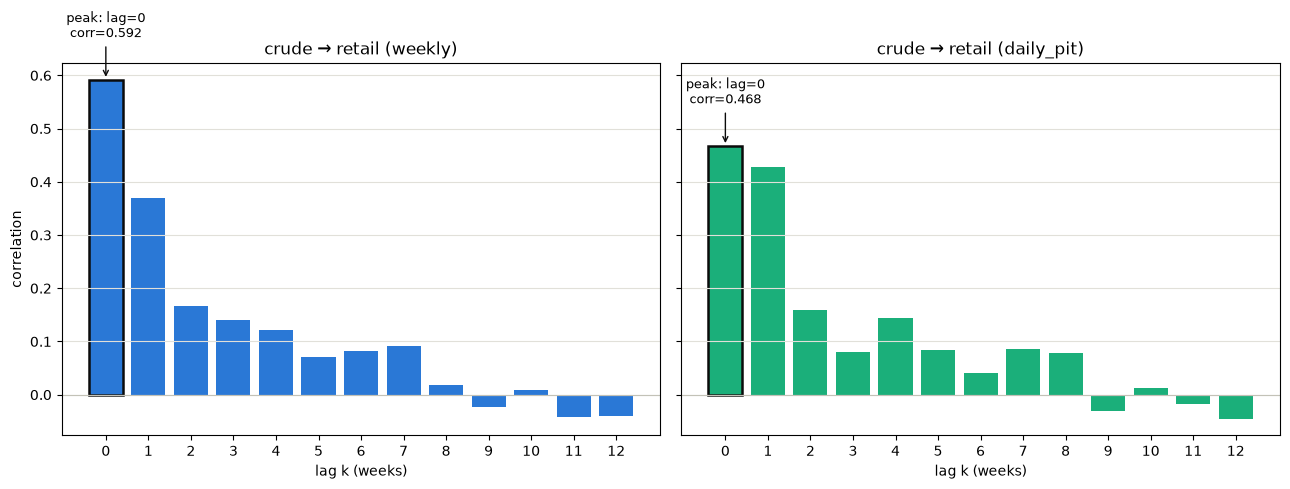

In [2]:
cc_crude_retail_weekly = cross_correlation(retail, weekly_crude, max_lag=MAX_LAG, mode="weekly")
cc_crude_retail_daily_pit = cross_correlation(retail, daily_crude, max_lag=MAX_LAG, mode="daily_pit")

fig, (ax_weekly, ax_daily_pit) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
plot_cross_correlation(ax_weekly, cc_crude_retail_weekly, COLOR_CRUDE_RETAIL_WEEKLY, "crude \u2192 retail (weekly)")
plot_cross_correlation(ax_daily_pit, cc_crude_retail_daily_pit, COLOR_CRUDE_RETAIL_DAILY_PIT, "crude \u2192 retail (daily_pit)")
ax_weekly.set_ylabel("correlation")
plt.tight_layout()
plt.show()

In [3]:
print("weekly:")
print(cc_crude_retail_weekly.to_string(index=False))
print()
print("daily_pit:")
print(cc_crude_retail_daily_pit.to_string(index=False))

weekly:
 lag  correlation  n_obs
   0     0.591955    864
   1     0.369347    863
   2     0.167108    862
   3     0.140093    861
   4     0.121797    860
   5     0.071414    859
   6     0.081881    858
   7     0.091964    857
   8     0.018915    856
   9    -0.023368    855
  10     0.008313    854
  11    -0.042579    853
  12    -0.039816    852

daily_pit:
 lag  correlation  n_obs
   0     0.467526    864
   1     0.428137    863
   2     0.158718    862
   3     0.079611    861
   4     0.144123    860
   5     0.084888    859
   6     0.040551    858
   7     0.086089    857
   8     0.077649    856
   9    -0.030079    855
  10     0.011778    854
  11    -0.018165    853
  12    -0.044831    852


## 2. Cross-correlation: crude → wholesale

**A technical note before the chart:** `WCOILWTICO` (weekly crude) and `WGASUSGULF` (weekly wholesale) are both Friday-dated on the *identical* calendar day — confirmed directly (`(crude['date'] == wholesale['date']).all()` is `True`). `align_retail_to_upstream`'s guard requires `upstream_date` strictly *before* the paired date, so pairing them both at `mode="weekly"` collides on every row and raises. This pair uses **daily** crude (`DCOILWTICO`) as the upstream series against weekly wholesale (playing the "retail" role) at `mode="daily_pit"` instead — the same fix `03_point_in_time.ipynb` used for the crude→retail robustness check, applied one link earlier in the chain.

**What this shows:** how far back a wholesale price move traces to crude, using the same alignment machinery as the primary pair — no ad-hoc join.

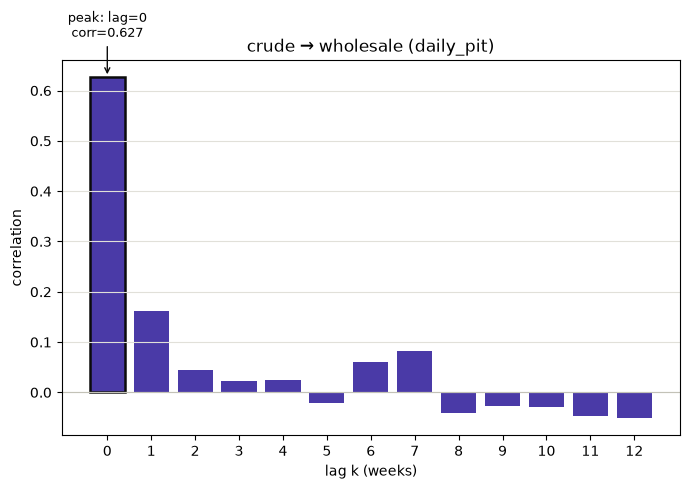

In [4]:
cc_crude_wholesale = cross_correlation(weekly_wholesale, daily_crude, max_lag=MAX_LAG, mode="daily_pit")

fig, ax = plt.subplots(figsize=(7, 5))
plot_cross_correlation(ax, cc_crude_wholesale, COLOR_CRUDE_WHOLESALE, "crude \u2192 wholesale (daily_pit)")
ax.set_ylabel("correlation")
plt.tight_layout()
plt.show()

In [5]:
cc_crude_wholesale

,lag,correlation,n_obs
0,0,0.626821,864
1,1,0.160982,863
2,2,0.045268,862
3,3,0.023275,861
4,4,0.024458,860
5,5,-0.021863,859
6,6,0.061161,858
7,7,0.083035,857
8,8,-0.041011,856
9,9,-0.026771,855


## 3. Cross-correlation: wholesale → retail
Weekly wholesale as upstream, retail as the survey series — the same clock relationship as the primary crude→retail pair (Friday upstream, Monday retail), so `mode="weekly"` applies directly with no adjustment.

**What this shows:** the second link's own lag profile, for direct comparison against section 2's first link — same chart type, same axes, so the shapes can be read side by side.

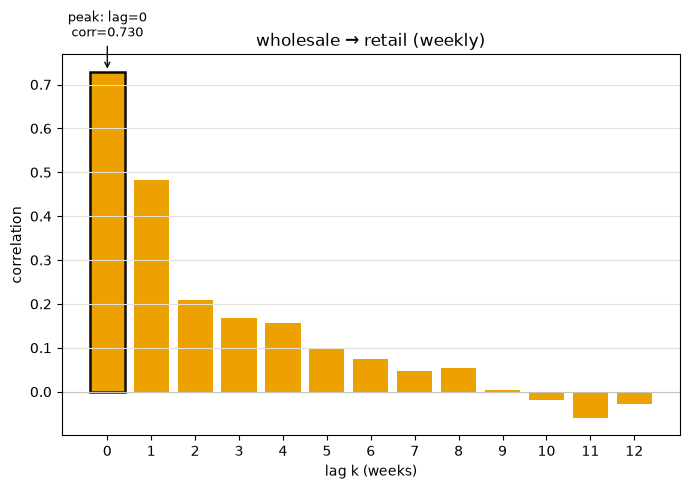

In [7]:
cc_wholesale_retail = cross_correlation(retail, weekly_wholesale, max_lag=MAX_LAG, mode="weekly")

fig, ax = plt.subplots(figsize=(7, 5))
plot_cross_correlation(ax, cc_wholesale_retail, COLOR_WHOLESALE_RETAIL, "wholesale \u2192 retail (weekly)")
ax.set_ylabel("correlation")
plt.tight_layout()
plt.show()

In [8]:
cc_wholesale_retail

,lag,correlation,n_obs
0,0,0.729599,864
1,1,0.482611,863
2,2,0.208491,862
3,3,0.167396,861
4,4,0.157346,860
5,5,0.099965,859
6,6,0.073732,858
7,7,0.047830,857
8,8,0.053003,856
9,9,0.004290,855


### Peaks, side by side
The four profiles' peak lag and correlation together, so the two links (and the two crude→retail alignments) can be compared at a glance without paging back through three charts.

In [9]:
def peak_row(name: str, result: pd.DataFrame) -> dict:
    idx = result["correlation"].idxmax()
    return {"pair": name, "peak_lag": result.loc[idx, "lag"], "peak_corr": result.loc[idx, "correlation"], "n_obs_at_peak": result.loc[idx, "n_obs"]}


peaks = pd.DataFrame(
    [
        peak_row("crude \u2192 retail (weekly)", cc_crude_retail_weekly),
        peak_row("crude \u2192 retail (daily_pit)", cc_crude_retail_daily_pit),
        peak_row("crude \u2192 wholesale (daily_pit)", cc_crude_wholesale),
        peak_row("wholesale \u2192 retail (weekly)", cc_wholesale_retail),
    ]
)
peaks

,pair,peak_lag,peak_corr,n_obs_at_peak
0,crude → retail (weekly),0,0.591955,864
1,crude → retail (daily_pit),0,0.467526,864
2,crude → wholesale (daily_pit),0,0.626821,864
3,wholesale → retail (weekly),0,0.729599,864


## 4. Up/down response: crude → retail (weekly)
`up_down_response`'s mean `delta_retail_{t+h}` following an up-week vs. a down-week in crude, h = 0..8, with ±1 SE error bars.

**Reminder from the function's own docstring:** this is descriptive only. It splits weeks by the *direction* of `delta_upstream` alone, never its size — a systematic difference in typical move-size between the two groups could produce a gap here even under perfectly symmetric response. It cannot establish asymmetry by itself.

**What this shows:** the shape of the two groups' means over time, plus how balanced the two groups actually are — printed below the chart, since an unbalanced split changes how much weight the comparison deserves.

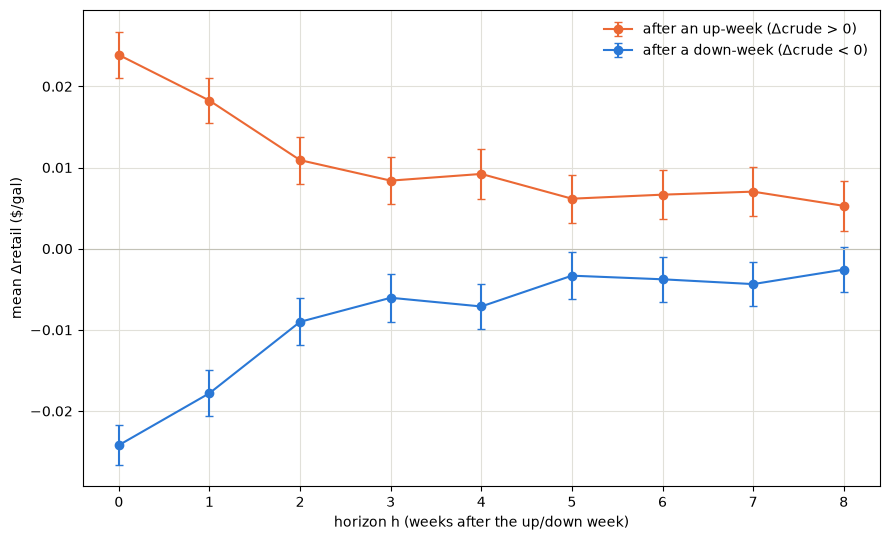

In [10]:
ud = up_down_response(retail, weekly_crude, horizon=8, mode="weekly")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(ud["horizon"], ud["mean_after_up"], yerr=ud["se_up"], marker="o", color=COLOR_UP, label="after an up-week (\u0394crude > 0)", capsize=3)
ax.errorbar(ud["horizon"], ud["mean_after_down"], yerr=ud["se_down"], marker="o", color=COLOR_DOWN, label="after a down-week (\u0394crude < 0)", capsize=3)

ax.set_xlabel("horizon h (weeks after the up/down week)")
ax.set_ylabel("mean \u0394retail ($/gal)")
ax.set_xticks(ud["horizon"])
ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [10]:
ud

,horizon,mean_after_up,mean_after_down,n_up,n_down,se_up,se_down
0,0,0.023872,-0.024202,462,401,0.002868,0.002426
1,1,0.018247,-0.017802,462,400,0.002770,0.002829
2,2,0.010911,-0.009010,461,400,0.002880,0.002901
3,3,0.008387,-0.006045,460,400,0.002898,0.002929
4,4,0.009211,-0.007118,459,400,0.003045,0.002719
5,5,0.006161,-0.003323,459,399,0.002962,0.002885
6,6,0.006658,-0.003769,459,398,0.003015,0.002792
7,7,0.007031,-0.004360,459,397,0.003044,0.002752
8,8,0.005279,-0.002573,459,396,0.003077,0.002735


In [11]:
n_up0, n_down0 = ud.loc[0, "n_up"], ud.loc[0, "n_down"]
total = n_up0 + n_down0
print(f"up/down balance at horizon=0: n_up={n_up0} ({n_up0/total:.1%}), n_down={n_down0} ({n_down0/total:.1%}), classified={total} of {len(retail)-1} possible weeks")

up/down balance at horizon=0: n_up=462 (53.5%), n_down=401 (46.5%), classified=863 of 864 possible weeks


## 5. Chosen lag lengths (K)

For each pair, K is set at the lag beyond which the cross-correlation stops being meaningfully different from noise, read off the bar charts and tables in sections 1–3.
The SPEC suggests up to 6.

**Noise reference used throughout:** an approximate 95% band of ±1.96/√n ≈ ±0.067 (n≈864) — the standard threshold for testing whether a correlation differs from zero under the null of no relationship at that lag. This is an approximation: it assumes the differenced series behave like white noise, which they only roughly do (some residual autocorrelation remains — see `lag_structure.py`'s docstring). Treated here as a guide to shape, not a formal significance test.

With 13 lags tested per pair, an occasional isolated value crossing the band by chance is expected even under a true null (≈13 × 5% ≈ 0.6 false positives per pair) — a single crossing with no supporting trend in its neighbors is read as noise, not signal.

### Crude → wholesale: K_cw = 1

Correlation collapses from 0.627 at lag 0 to 0.161 at lag 1, then to 0.045 at lag 2 — already inside the noise band. From lag 2 through lag 12 the values scatter around zero with no decay trend; one isolated value at lag 7 (0.083) sits just above the band, but with in-band neighbors on both sides and no economic story attached to week 7 specifically. K_cw = 1 captures the whole signal: wholesale reacts to crude almost entirely within the same week, consistent with both being continuously traded, arbitraged markets.

### Wholesale → retail: K_wr = 6

Decay is far slower here: 0.730 → 0.483 → 0.208 → 0.167 → 0.157 → 0.100 → 0.074 → 0.048 across lags 0–7. Lag 6 (0.074) sits at the edge of the noise band; lag 7 (0.048) is clearly inside it. Unlike crude → wholesale, this is a genuine multi-week decay rather than a spike-then-flat shape — consistent with retail margin stickiness (menu costs, competitive-matching delay) rather than fast pass-through. K_wr = 6 is where the decay visibly crosses into noise; further lags would add coefficients with nothing behind them.

### Crude → retail (weekly, primary spec): K_cr = 4

Correlation decays cleanly through lag 4 (0.592 → 0.369 → 0.167 → 0.140 → 0.122), dips to 0.071 at lag 5 (noise edge), then shows a secondary bump at lags 6–7 (0.082, 0.092) before collapsing after lag 8. K꜀ᵣ = 4 is set on the clean part of the decay; the lag 6–7 bump is not included in the choice — it isn't supported by its neighbors (a dip before, a collapse after), the shape expected from scanning 13 lags under the null rather than a real tertiary effect. The `daily_pit` comparison (03_point_in_time) is consistent with a conservative K here rather than an argument to extend it: its lag 0 and lag 1 are nearly tied (0.468 vs 0.428), where the weekly series shows a sharp drop (0.592 vs 0.369) — suggesting the weekly regressor's within-week averaging folds some genuine lag-1 response into what reads as lag 0. K = 4 already accounts for that possibility; it doesn't need to be raised because of it.

Fit at K = 6 as a sensitivity check, to confirm the up/down asymmetry conclusion doesn't depend on whether the lag 6–7 bump is in the model.

### Consistency across the decomposition

K_cw (1) + K_wr (6) ≈ 7, which roughly matches where the direct crude → retail pair's own tail dies out (lags 6–8). The two-link decomposition and the direct pair are describing the same underlying process — a useful cross-check, not a constraint imposed in advance.